In [65]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import os
import sys
import json
import numpy as np
import pandas as pd
from statistics import  mean, multimode

In [67]:
main_dir = os.path.dirname(os.getcwd())
BASE_DIR   = os.path.join(main_dir, "facet_data")
IMG_DIRS   = [os.path.join(BASE_DIR, d) for d in ("imgs_1", "imgs_2", "imgs_3")]
ANN_FILE   = os.path.join(BASE_DIR, "annotations", "annotations.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "facet_dataset.csv")

In [68]:
df_ann = pd.read_csv(ANN_FILE)

df_ann_new = df_ann.copy()

# 2) Detectar columnas de frecuencia de skin tone (1–10)
skin_cols = [c for c in df_ann_new.columns if c.startswith("skin_tone_") and c != "skin_tone_na"]

mask_any = df_ann_new[skin_cols].sum(axis=1) > 0
df_ann_new = df_ann_new[mask_any].reset_index(drop=True)

counts = df_ann_new.groupby("filename").size()
single_person_images = counts[counts == 1].index.tolist()

df_ann_single_person = df_ann_new[df_ann_new['filename'].isin(single_person_images)].reset_index(drop=True)


df_ann_single_person['bbox_dict'] = df_ann_single_person['bounding_box'].apply(json.loads)
df_ann_single_person[['x','y','width','height']] = df_ann_single_person['bbox_dict'].apply(
    lambda b: pd.Series([b['x'], b['y'], b['width'], b['height']]))

# 3) Función para elegir el tono más frecuente (tie‐break: mayor valor)
# def pick_by_freq(row):
#     freqs     = row[skin_cols]
#     max_count = freqs.max()                       # p. ej. 2
#     # extraigo todos los tonos que alcanzan ese count
#     candidates = [int(col.split('_')[-1])
#                     for col in skin_cols
#                     if row[col] == max_count]
#     return max(candidates) if candidates else None

# Función para elegir el tono de piel final por promedio ponderado
def pick_by_weighted_average(row, skin_cols):
    total_votes = 0
    weighted_sum = 0
    
    for col in skin_cols:
        # Extraer el valor numérico del tono de piel (ej. de 'skin_tone_1' a 1)
        tone_value = int(col.split('_')[-1]) 
        # Obtener la frecuencia (votos) para ese tono
        frequency = row[col]
        
        weighted_sum += (tone_value * frequency)
        total_votes += frequency
    
    if total_votes == 0:
        return None # No hay votos de tono de piel, maneja como prefieras
    
    weighted_average = weighted_sum / total_votes
    final_tone = int(round(weighted_average))
    final_tone = max(1, min(10, final_tone)) # Asegurar que el tono esté en el rango 1-10
    return final_tone

# df_ann_single_person['skin_tone_final'] = df_ann_single_person.apply(pick_by_freq, axis=1)
df_ann_single_person['skin_tone_final'] = df_ann_single_person.apply(
    lambda row: pick_by_weighted_average(row, skin_cols), axis=1)

path_dict = {}
for img_dir in IMG_DIRS:
    for fname in os.listdir(img_dir):
        if fname.lower().endswith('.jpg'):
            path_dict[fname] = os.path.join(img_dir, fname)
df_ann_single_person.loc[:, 'image_path'] = df_ann_single_person['filename'].map(path_dict)
# 4) Construir DataFrame con persona + coords + tono
df_ann_out = df_ann_single_person[[
    'image_path',
    'filename',
    'person_id',
    'x','y','width','height',
    'skin_tone_final'
]]

In [69]:
df_ann_out

,image_path,filename,person_id,x,y,width,height,skin_tone_final
0,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_3...,sa_3532701.jpg,350155620665729,120.66,629.34,934.54,591.48,2
1,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_7...,sa_7347673.jpg,351314803874856,1674.89,668.60,404.47,831.30,3
2,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_1...,sa_1666366.jpg,353890693618765,520.21,35.11,1423.40,1448.94,2
3,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_1...,sa_10549407.jpg,356306116703746,1065.63,274.00,98.53,429.88,4
4,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_3...,sa_3536267.jpg,356965596647816,788.30,165.96,523.40,935.11,6
...,...,...,...,...,...,...,...,...
20793,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_9...,sa_9826612.jpg,9119254418088320,429.32,958.06,533.26,1152.38,8
20794,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_4...,sa_4602180.jpg,9172475139444955,114.89,6.38,1755.32,1468.09,4
20795,/home/diegopaez/MoQ-NAS/facet_data/imgs_2/sa_1...,sa_10528743.jpg,9211383438887944,0.00,366.58,1498.65,1625.34,2
20796,/home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_9...,sa_9291116.jpg,9263831723642501,518.84,601.03,626.71,1263.70,3


In [70]:
# print the values of df_ann for the skin_cols 
count = 0
for file_name in df_ann_out['filename'].unique():
    print(f"File: {file_name}")
    sample_df = df_ann[df_ann['filename'] == file_name]
    for col in skin_cols:
        print(f"{col}: {sample_df[col].values[0]}")
    print(f"Skin Tone Final: {df_ann_out[df_ann_out['filename'] == file_name]['skin_tone_final'].values[0]}")
    print('--'* 20)
    count += 1
    if count > 10:
        break

File: sa_3532701.jpg
skin_tone_1: 2
skin_tone_2: 3
skin_tone_3: 0
skin_tone_4: 0
skin_tone_5: 0
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 2
----------------------------------------
File: sa_7347673.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 2
skin_tone_4: 0
skin_tone_5: 0
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 3
----------------------------------------
File: sa_1666366.jpg
skin_tone_1: 1
skin_tone_2: 3
skin_tone_3: 1
skin_tone_4: 0
skin_tone_5: 0
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 2
----------------------------------------
File: sa_10549407.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 1
skin_tone_4: 2
skin_tone_5: 1
skin_tone_6: 0
skin_tone_7: 0
skin_tone_8: 0
skin_tone_9: 0
skin_tone_10: 0
Skin Tone Final: 4
----------------------------------------
File: sa_3536267.jpg
skin_tone_1: 0
skin_tone_2: 0
skin_tone_3: 0
skin_

In [71]:
out_path = os.path.join(BASE_DIR, 'facet_dataset_coords.csv')
df_ann_out.to_csv(out_path, index=False)

In [73]:
print("Número de filas en el dataset final:", len(df_ann_out))
# Cuenta cuántas personas hay por imagen en el dataset final
final_counts = df_ann_out.groupby('filename').size()
# Muestra imágenes que aún tienen más de una persona
multi_person_in_final = final_counts[final_counts > 1]
print("Imágenes con más de una persona en el dataset final (debería ser 0):", len(multi_person_in_final))


Número de filas en el dataset final: 20798
Imágenes con más de una persona en el dataset final (debería ser 0): 0


In [72]:
from torch.utils.data import DataLoader, Dataset, random_split

In [83]:
class FacetDataset(Dataset):
    """
    FACET Dataset a partir de CSV con columnas:
        - image_path: ruta al archivo .jpg
        - x, y, width, height: coordenadas de la bounding box
        - skin_tone_final: tono consolidado (1–10)
    """
    def __init__(self, csv_path, transform=None):
        # 1) Cargo el CSV
        df = pd.read_csv(csv_path)
        # 2) Extraigo las columnas que voy a usar
        self.samples = list(df[[
            "image_path", "x", "y", "width", "height", "skin_tone_final"
        ]].itertuples(index=False, name=None))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # 3) Desempaqueto sample
        path, x, y, w, h, tone = self.samples[idx]
        print(f"Procesando imagen: {path} con tono: {tone}")
        # 4) Cargo imagen y recorto la región de interés
        img = Image.open(path).convert("RGB")
        # PIL.crop recibe (left, upper, right, lower)
        # left   = int(round(x))
        # upper  = int(round(y))
        # right  = int(round(x + w))
        # lower  = int(round(y + h))
        # face = img.crop((left, upper, right, lower))
        # 5) Aplico transform si lo hay
        if self.transform:
            img = self.transform(img)
        # 6) Devuelvo el recorte y el label de tono
        return img, tone

In [85]:
ds = FacetDataset(out_path)

Procesando imagen: /home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_9148011.jpg con tono: 4
Procesando imagen: /home/diegopaez/MoQ-NAS/facet_data/imgs_1/sa_10455098.jpg con tono: 4
Procesando imagen: /home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_8371400.jpg con tono: 5
Procesando imagen: /home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_8835777.jpg con tono: 6
Procesando imagen: /home/diegopaez/MoQ-NAS/facet_data/imgs_3/sa_4000707.jpg con tono: 4


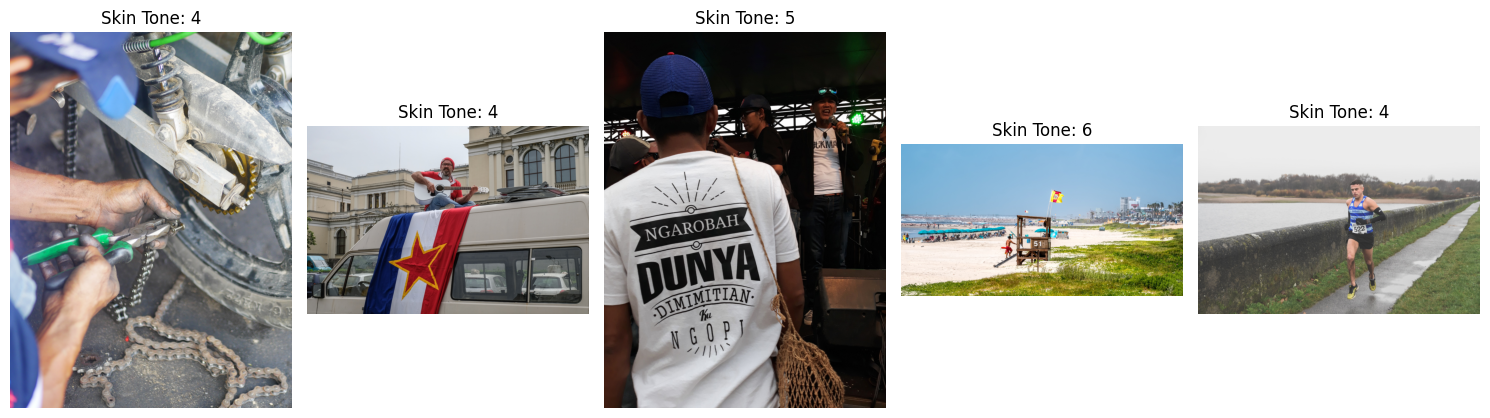

In [91]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_samples(dataset, n=5):
    # Asegurarse de que n no sea mayor que el tamaño del dataset
    n = min(n, len(dataset))
    
    # Seleccionar aleatoriamente n índices únicos del dataset
    indices = random.sample(range(len(dataset)), n)
    
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    for idx, ax in zip(indices, axes):
        img, tone = dataset[idx]
        ax.imshow(img)
        ax.set_title(f"Skin Tone: {tone}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Ejemplo de uso
show_samples(ds, n=5)

In [92]:
df_ann[df_ann['filename'] == 'sa_8371400.jpg']

,Unnamed: 0,person_id,filename,class1,class2,bounding_box,gender_presentation_masc,gender_presentation_fem,gender_presentation_non_binary,gender_presentation_na,...,has_headscarf,has_eyeware,visible_torso,visible_face,visible_minimal,lighting_underexposed,lighting_dimly_lit,lighting_well_lit,lighting_na,lighting_overexposed
34967,34967,1229442760936437,sa_8371400.jpg,singer,NaN,"{""x"": 987.5, ""y"": 275, ""width"": 404.17, ""heigh...",1,0,0,0,...,0,1,1,1,0,1,0,0,0,0


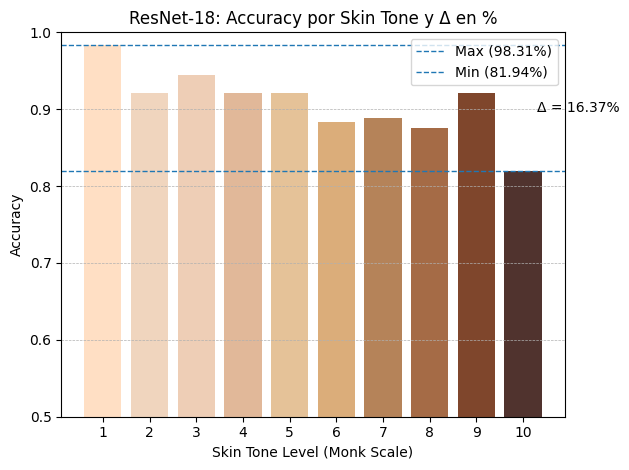

In [3]:
import matplotlib.pyplot as plt

def plot_skin_tone_accuracy(accuracies, model_name):
    """
    Dibuja un gráfico de barras de accuracy por nivel de skin tone (Monk Scale),
    con líneas punteadas para Max y Min, y anotación de Δ en porcentaje.
    
    Parámetros:
    - accuracies: lista de floats con accuracy para cada tono (1–10).
    - model_name: string con el nombre del modelo (usado en el título).
    """
    tones = list(range(1, len(accuracies) + 1))
    
    # Colores de la escala Monk Skin Tone
    monk_colors = [
        "#FFDFC4", "#F0D5BE", "#EECEB6", "#E1B899", "#E5C298",
        "#DBAD7A", "#B58359", "#A56B46", "#7F462C", "#50332E"
    ][:len(tones)]
    
    # Cálculo de max, min y delta
    max_acc = max(accuracies)
    min_acc = min(accuracies)
    delta = max_acc - min_acc
    
    # Creación de la figura
    fig, ax = plt.subplots()
    
    # Gráfico de barras
    ax.bar(tones, accuracies, color=monk_colors)
    
    # Líneas de Max y Min
    ax.axhline(max_acc, linestyle='--', linewidth=1, label=f'Max ({max_acc*100:.2f}%)')
    ax.axhline(min_acc, linestyle='--', linewidth=1, label=f'Min ({min_acc*100:.2f}%)')
    
    # Anotación de Δ en la derecha
    x_text = tones[-1] + 0.3
    y_text = (max_acc + min_acc) / 2
    ax.text(x_text, y_text, f'Δ = {delta*100:.2f}%', va='center')
    
    # Configuraciones
    ax.set_xticks(tones)
    ax.set_xlabel("Skin Tone Level (Monk Scale)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model_name}: Accuracy por Skin Tone y Δ en %")
    ax.set_ylim(0.5, 1.0)
    ax.legend()
    ax.grid(axis="y", linestyle="--", linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    return fig, ax

# Ejemplo de uso con ResNet-18
accuracies_resnet = [0.9831,0.9216,0.9444,0.9206,0.9205,0.8828,0.8888,0.8755,0.9206,0.8194,]
plot_skin_tone_accuracy(accuracies_resnet, "ResNet-18");


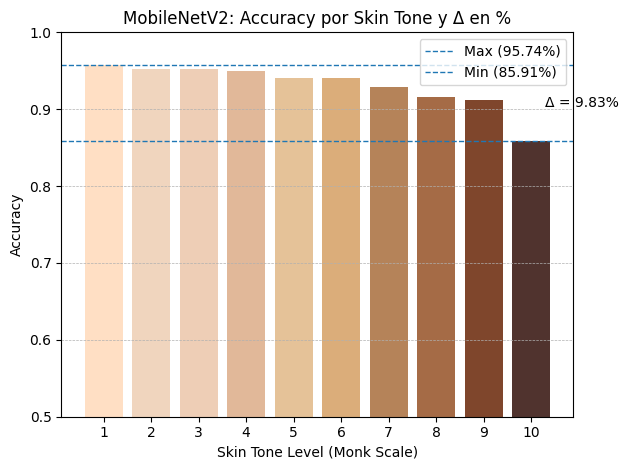

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'MobileNetV2: Accuracy por Skin Tone y Δ en %'}, xlabel='Skin Tone Level (Monk Scale)', ylabel='Accuracy'>)

In [12]:
accuracies_mobilenet = [0.9574,0.9526,0.9517,0.9499,0.9406,0.9403,0.9290,0.9155,0.9124,0.8591]
plot_skin_tone_accuracy(accuracies_mobilenet, "MobileNetV2")